In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta
@load "mean_traj_OU.jld2" mean_traj
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [2]:
@load "metrics_all.jld2" metrics_all
@load "dc_delta_all.jld2" dc_delta_all


1-element Vector{Symbol}:
 :dc_delta_all

In [2]:
@load "second_redo.jld2" sorted_metrics
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

In [18]:
dc_delta = dc_delta_all[dc_delta_all.n .!= 0.25, :]

Row,tm,n,v,Dc,delta,l,Lambda,eq,threshold
,Int64,Float64,Int64,Float64,Float64,Float64,String15,Int64,Int64
1,1,0.5,10,20.0,0.005,63.2456,"0,158113883",50000,75
2,1,0.75,10,13.3333,0.0075,42.1637,"0,2371708245",50000,75
3,1,1.0,10,10.0,0.01,31.6228,"0,316227766",50000,75
4,1,2.0,10,5.0,0.02,15.8114,"0,632455532",50000,50
5,1,3.0,10,3.33333,0.03,10.5409,"0,9486832981",50000,50
6,1,4.0,10,2.5,0.04,7.90569,"1,264911064",50000,50
7,1,5.0,10,2.0,0.05,6.32456,"1,58113883",50000,50
8,1,6.0,10,1.66667,0.06,5.27046,"1,897366596",50000,50
9,1,7.0,10,1.42857,0.07,4.51754,"2,213594362",50000,50


In [7]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        # Standard OU step
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ
        
        # OPTIONAL: If you strictly need non-negative distance, 
        # use reflection or a softer boundary, not a hard clamp to 0.
        # For now, let's remove the clamp to see the true OU behavior.
        # If r represents displacement, negative values are fine.
        # If r MUST be distance, consider a Bessel process or |r|.
        # r[i] = abs(r[i]) 
    end

    return r
end

function run_simulations_and_get_means(dc_delta, metrics_combined, n_agents=1000, dt=0.01, T=600)
    results = []

    for i in 1:nrow(dc_delta)
        row = dc_delta[i, :]
        v = row[:v]
        tm = row[:tm]
        lambda = row[:n]
        Dc = row[:Dc]
        delta = row[:delta]

        l = sqrt(mean(Dc) / mean(delta))
        r0 = l * 2.5 

        mask = (metrics_combined.v .== v) .& (metrics_combined.l .== lambda) .& (metrics_combined.tm .== tm)

        k = metrics_combined.k[mask][1]



        # CORRECTED FORMULA: Variance = D / k  =>  D = sigma^2 * k
        D = metrics_combined.D[mask][1]

        # Generate 500 trajectories (or n_agents)
        trajectory_sum = zeros(Int(T/dt))

        for agent in 1:n_agents
            traj = simulate_OU(k, D, dt, T, r0)
            trajectory_sum .+= traj
        end

        mean_1 = trajectory_sum / n_agents

        push!(results, Dict(
            :v => v,
            :tm => tm,
            :lambda => lambda,
            :Dc => Dc,
            :delta => delta,
            :k => k,
            :D => D,
            :r0 => r0,
            :mean => mean_1
        ))
    end
   
    df_means = DataFrame(results)
    return df_means
end

run_simulations_and_get_means (generic function with 4 methods)

In [19]:
mean_traj_redo = run_simulations_and_get_means(dc_delta, metrics_all)

Row,lambda,mean,k,v,D,tm,Dc,delta,r0
,Float64,Array…,Float64,Int64,Float64,Int64,Float64,Float64,Float64
1,0.5,"[158.114, 157.851, 157.58, 157.347, 157.103, 156.873, 156.633, 156.404, 156.17, 155.939 … 0.122613, 0.0999419, 0.110454, 0.143088, 0.152879, 0.14233, 0.1498, 0.152315, 0.160468, 0.172377]",0.143217,10,18.6937,1,20.0,0.005,158.114
2,0.75,"[105.409, 105.25, 105.081, 104.906, 104.74, 104.543, 104.377, 104.197, 104.024, 103.878 … 0.141965, 0.0959218, 0.0901126, 0.101124, 0.106238, 0.0949437, 0.054942, 0.0449463, 0.0377379, 0.00600453]",0.161834,10,16.5766,1,13.3333,0.0075,105.409
3,1.0,"[79.0569, 78.9064, 78.7555, 78.6027, 78.4619, 78.3064, 78.1672, 78.0325, 77.8672, 77.7403 … -0.424159, -0.401765, -0.386075, -0.352818, -0.355716, -0.334944, -0.340374, -0.329341, -0.340575, -0.321617]",0.172307,10,14.9556,1,10.0,0.01,79.0569
4,2.0,"[39.5285, 39.4438, 39.372, 39.2963, 39.235, 39.1516, 39.07, 38.9697, 38.8759, 38.8025 … 0.0934161, 0.102583, 0.114941, 0.124692, 0.155193, 0.143893, 0.146228, 0.136794, 0.158487, 0.151174]",0.192667,10,11.3151,1,5.0,0.02,39.5285
5,3.0,"[26.3523, 26.31, 26.2513, 26.1825, 26.1354, 26.0796, 26.0566, 26.0186, 25.963, 25.9169 … -0.347884, -0.353001, -0.340271, -0.338904, -0.334651, -0.356378, -0.345612, -0.352015, -0.310583, -0.300899]",0.189426,10,8.97496,1,3.33333,0.03,26.3523
6,4.0,"[19.7642, 19.747, 19.706, 19.6522, 19.619, 19.5948, 19.5604, 19.5367, 19.4969, 19.4472 … -0.104963, -0.114704, -0.127589, -0.129, -0.105057, -0.0860511, -0.0825082, -0.0979146, -0.0906735, -0.0830073]",0.197183,10,8.01363,1,2.5,0.04,19.7642
7,5.0,"[15.8114, 15.806, 15.7962, 15.789, 15.7704, 15.7246, 15.6685, 15.6491, 15.6077, 15.5553 … 0.223417, 0.23243, 0.229351, 0.221263, 0.229844, 0.217249, 0.213951, 0.215093, 0.218322, 0.206937]",0.201452,10,7.25559,1,2.0,0.05,15.8114
8,6.0,"[13.1762, 13.135, 13.097, 13.079, 13.0665, 13.0471, 13.0136, 12.9938, 12.9578, 12.937 … -0.177173, -0.164796, -0.160632, -0.175886, -0.167344, -0.182526, -0.172363, -0.163272, -0.169482, -0.173403]",0.203223,10,6.70883,1,1.66667,0.06,13.1762
9,7.0,"[11.2938, 11.2776, 11.2583, 11.2361, 11.2276, 11.2081, 11.1897, 11.1649, 11.1195, 11.0977 … -0.110456, -0.107927, -0.0822607, -0.0777701, -0.0997908, -0.0990591, -0.0999918, -0.108776, -0.116403, -0.108557]",0.203809,10,6.30177,1,1.42857,0.07,11.2938


In [24]:
@save "mean_OU_all.jld2" mean_traj_redo

In [30]:
df = combined_dfs[(20.0, 0.25)]
grouped = groupby(df, :step)
mean(grouped[1].x)

631.8021688807576

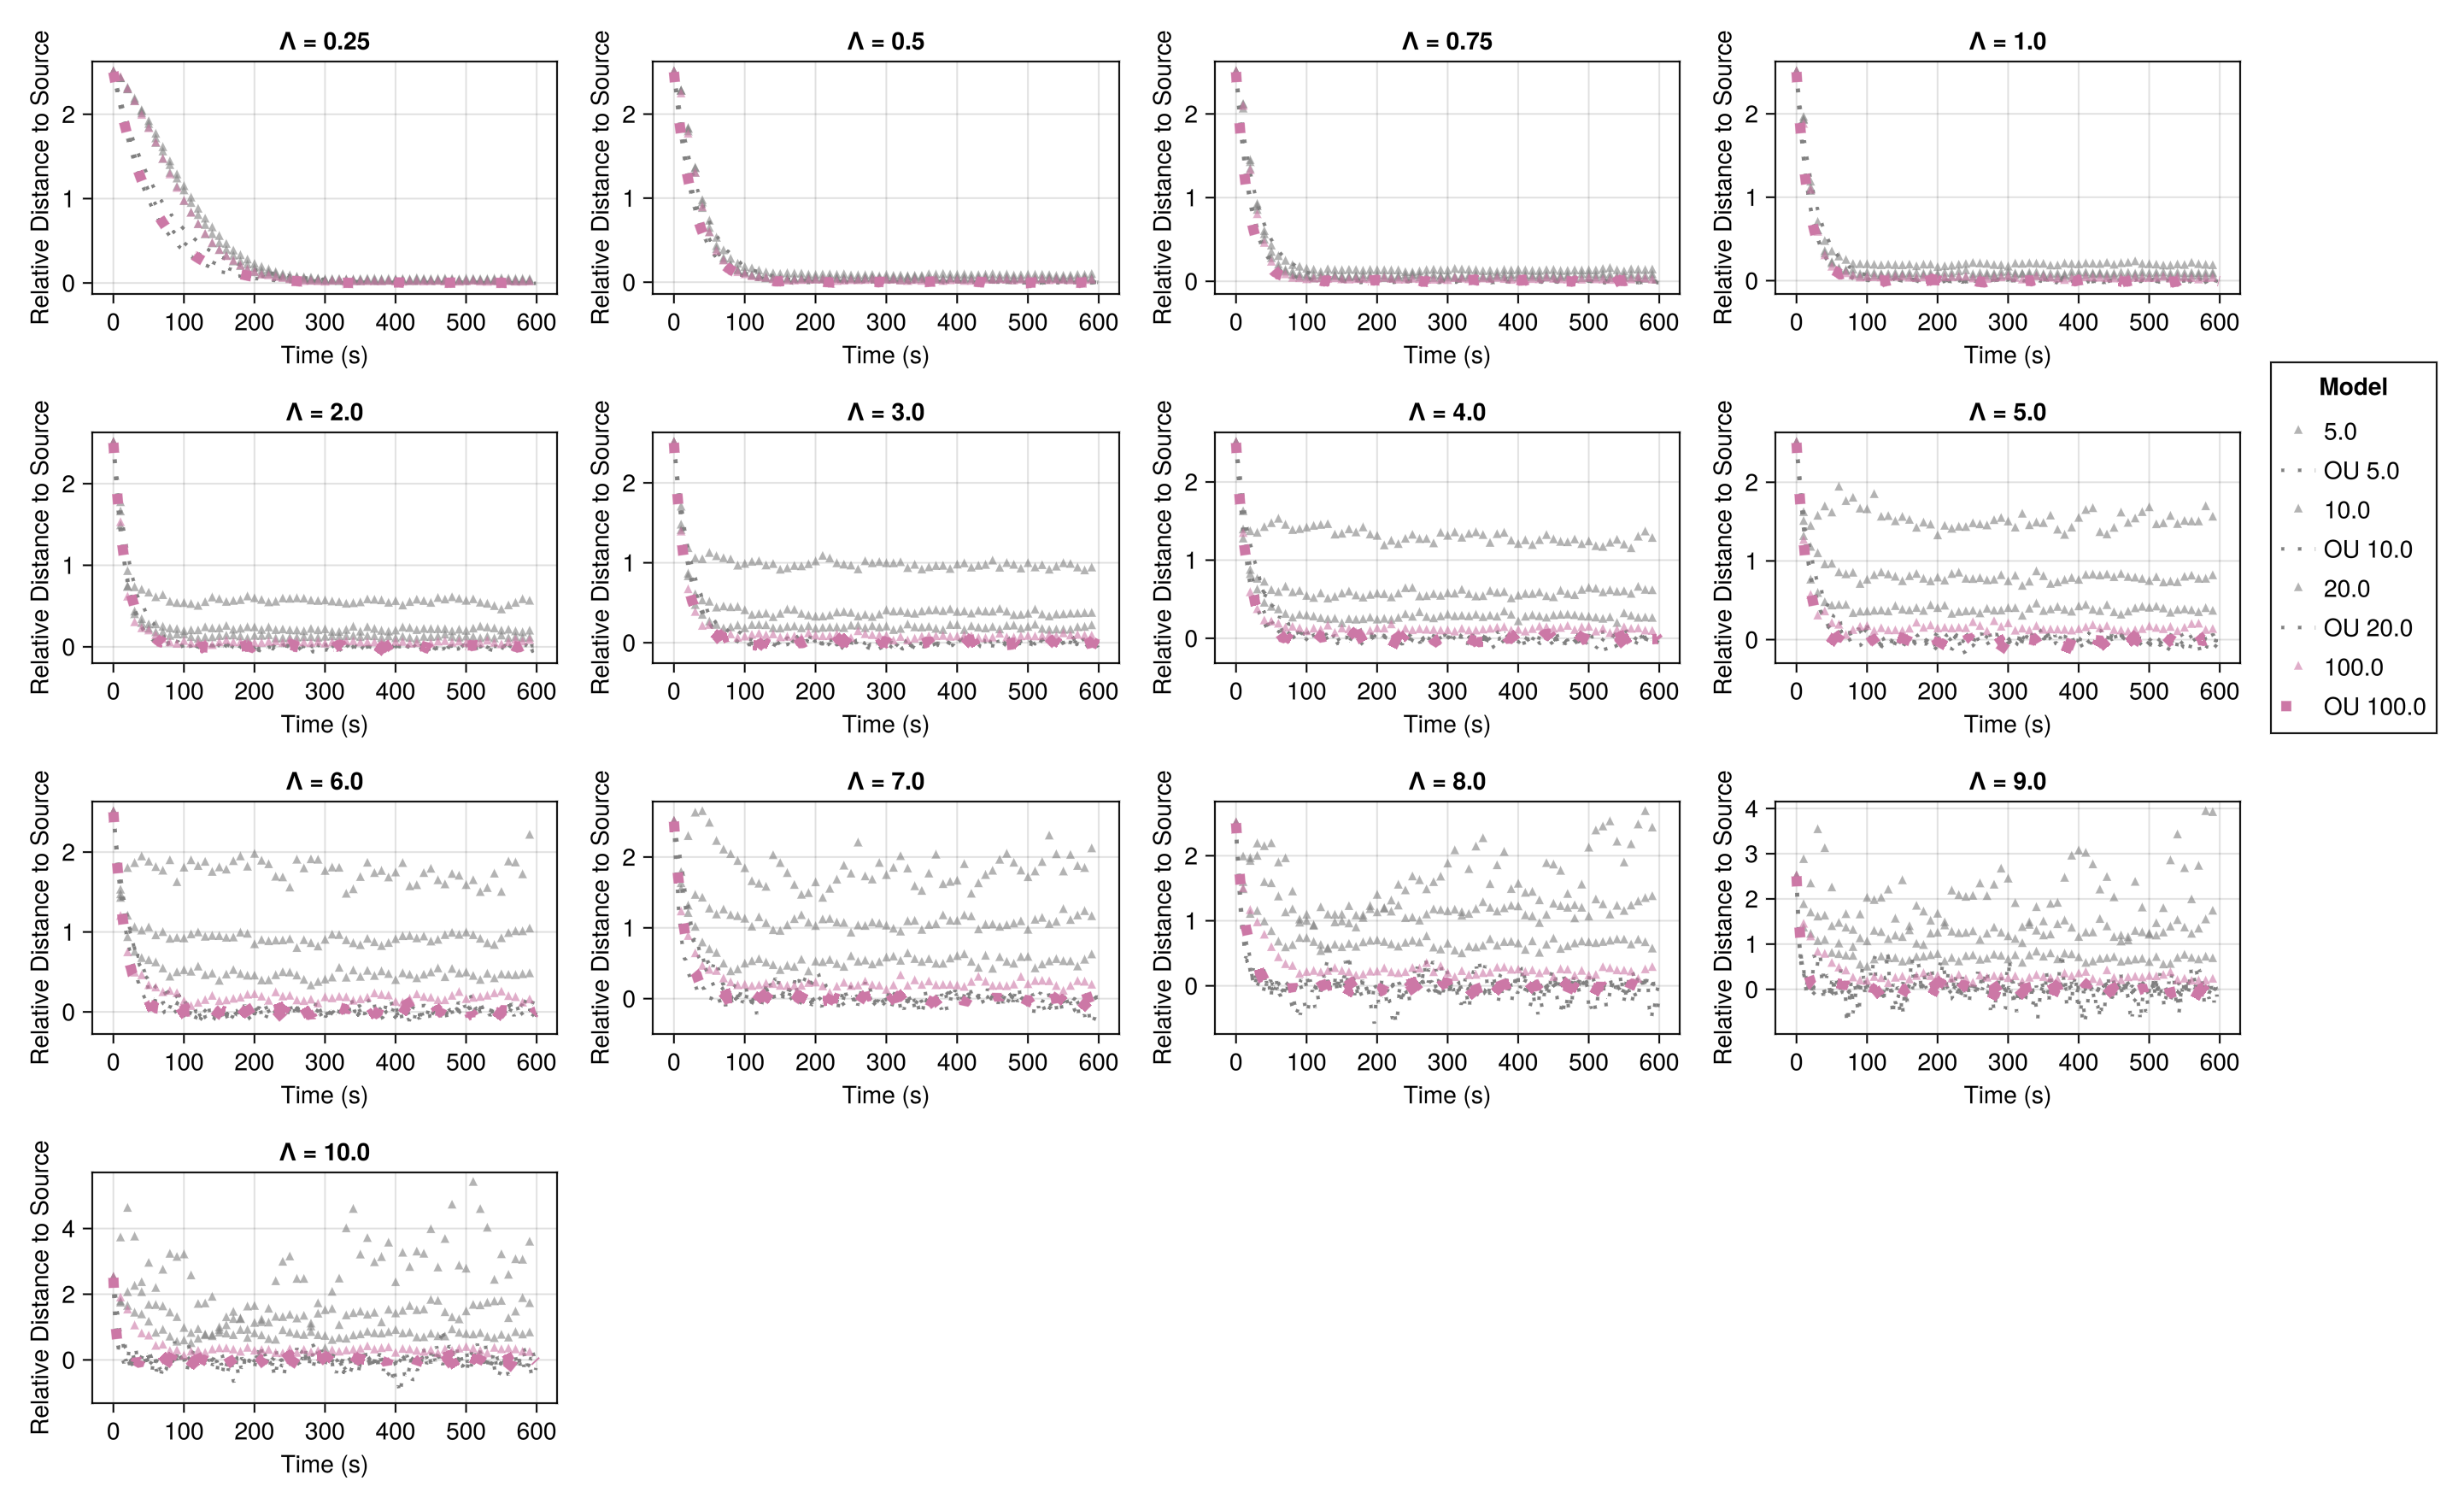

GLMakie.Screen(...)

In [10]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

# colors = distinguishable_colors(4, [RGB(1,1, 1), RGB(0, 0, 0)], dropseed = true, lchoices=range(70, stop=95, length = 15), cchoices=range(10, stop=40, length=15))
# colors = distinguishable_colors(
#     4,
#     [RGB(1,1,1), RGB(0,0,0)],
#     dropseed = true,
#     lchoices = range(50, stop=85, length=20),
#     cchoices = range(30, stop=80, length=20)
# )
# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    :grey,   # blue
    :grey,   # orange
    :grey,  # green
    RGBf(0.80, 0.47, 0.65) # magenta
]
# colors = [:red, :blue, :green, :yellow]
# colors_2 = [:pink, :black, :brown, :orange]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

widths = [2, 2, 2, 6]


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:100:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj.lambda .== lambda) .& (mean_traj.v .== v) 

        mean_OU = mean_traj.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        scatter!(ax_x, (1:100:length(grouped_t))*0.1, mean_x, color = color, label = "$v", alpha = 0.6, marker = :utriangle, markersize = 7, strokecolor = :black)
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = widths[v_idx], label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [11]:
save("Plots/Fixed_source_model/OU/OU_all_v100.png", fig2)

In [11]:
@load "redo_dfs.jld2" dfs_redo

1-element Vector{Symbol}:
 :dfs_redo

In [21]:
@load "dfs_all.jld2" dfs_all


1-element Vector{Symbol}:
 :dfs_all

In [23]:
# lambdas = [0.25, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000


# velocities = [5.0]
# velocities = [10.0]
velocities = [20.0]
# velocities = [100.0]

# id_to_color = Dict(1:4 .=> colors)
# colors = [
#     RGBf(0.0, 0.45, 0.70),   # blue
#     RGBf(0.90, 0.62, 0.0),   # orange
#     RGBf(0.0, 0.62, 0.45),   # green
#     RGBf(0.80, 0.47, 0.65)   # magenta
# ]
colors = [
    RGBf(0.80, 0.47, 0.65)
]


# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))

for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_all[(2.0, v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.n .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            # r = sqrt.(data_1.x .^ 2 .+ data_1.y .^ 2)
            # rl = r ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OUl = mean_OU ./ l 
        flat_vec = vcat(mean_OUl...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 4, label = "OU $v")


        if idx == 13 & v_idx == 1
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

ComputePipeline.ResolveException{ReadOnlyMemoryError}: Failed to resolve gl_renderobject:
[ComputeEdge] gl_renderobject = #171((space, scaled_color, alpha_colormap, scaled_colorrange, positions_transformed_f32c, indices, uniform_pattern, uniform_pattern_length, linecap, uniform_linewidth, scene_origin, model_f32c, lowclip_color, highclip_color, nan_color, debug, uniform_clip_planes, uniform_num_clip_planes, depth_shift, visible, fxaa, resolution, projection, projectionview, view, upvector, eyeposition, view_direction, ), changed, cached)
  @ C:\Users\ibzja\.julia\packages\GLMakie\vdrwE\src\plot-primitives.jl:245
  with edge inputs:
    space = :data
    scaled_color = RGBA{Float32}[]
    alpha_colormap = RGBA{Float32}[RGBA{Float32}(0.267004f0,0.004874f0,0.329415f0,1.0f0), RGBA{Float32}(0.26851f0,0.009605f0,0.335427f0,1.0f0), RGBA{Float32}(0.269944f0,0.014625f0,0.341379f0,1.0f0), RGBA{Float32}(0.271305f0,0.019942f0,0.347269f0,1.0f0), RGBA{Float32}(0.272594f0,0.025563f0,0.353093f0,1.0f0)

In [21]:
save("Plots/Fixed_source_model/Next/OU_v20_new.png", fig2)

In [42]:
@save "mean_traj_OU.jld2" mean_traj

In [5]:
@load "mean_traj_OU.jld2" mean_traj

1-element Vector{Symbol}:
 :mean_traj

In [ ]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OU_norm = mean_OU ./ l 
        flat_vec = vcat(mean_OU_norm...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)